# Lesson 4: Denoising Autoencoder для Fashion-MNIST

CNN-автоэнкодер для удаления гауссовского шума. Есть подбор гиперпараметров, финальное обучение, метрики и визуализации.


In [1]:
import importlib
import importlib.util
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import ConcatDataset, DataLoader, random_split
from torchvision import datasets, transforms

if importlib.util.find_spec("optuna") is None:
    raise ImportError("Optuna is required. Install it with: python -m pip install optuna")
optuna = importlib.import_module("optuna")

SKLEARN_AVAILABLE = importlib.util.find_spec("sklearn") is not None
if not SKLEARN_AVAILABLE:
    print("scikit-learn not found: PCA fallback will use PyTorch, t-SNE will be skipped.")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


Device: cpu


## Гиперпараметры

Используется Optuna: она подбирает `latent_dim`, `lr`, `weight_decay`, затем финальная модель обучается с `best_config`.


In [2]:
BATCH_SIZE = 128
OPTUNA_TRIALS = 10
SEARCH_EPOCHS = 2
FINAL_EPOCHS = 8

NOISE_STD_MIN = 0.1
NOISE_STD_MAX = 0.8
EVAL_NOISE_STDS = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

DATA_DIR = "./data"
print(f"Optuna trials: {OPTUNA_TRIALS}")


Optuna trials: 10


## Данные

Fashion-MNIST делится на `60/20/20`: обучение, валидация, тест.


In [3]:
transform = transforms.ToTensor()
train_raw = datasets.FashionMNIST(
    root=DATA_DIR,
    train=True,
    download=True,
    transform=transform,
)
test_raw = datasets.FashionMNIST(
    root=DATA_DIR,
    train=False,
    download=True,
    transform=transform,
)
full_dataset = ConcatDataset([train_raw, test_raw])
total_size = len(full_dataset)
train_size = int(0.60 * total_size)
val_size = int(0.20 * total_size)
test_size = total_size - train_size - val_size
split_generator = torch.Generator().manual_seed(SEED)
train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=split_generator,
)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
)
classes = train_raw.classes
print(f"Train: {len(train_dataset)}")
print(f"Validation: {len(val_dataset)}")
print(f"Test: {len(test_dataset)}")


Train: 42000
Validation: 14000
Test: 14000


## Шум

На обучении используется случайный `std` из `[0.1, 0.8]`; на оценке проверяются фиксированные уровни от `0.1` до `0.8`.


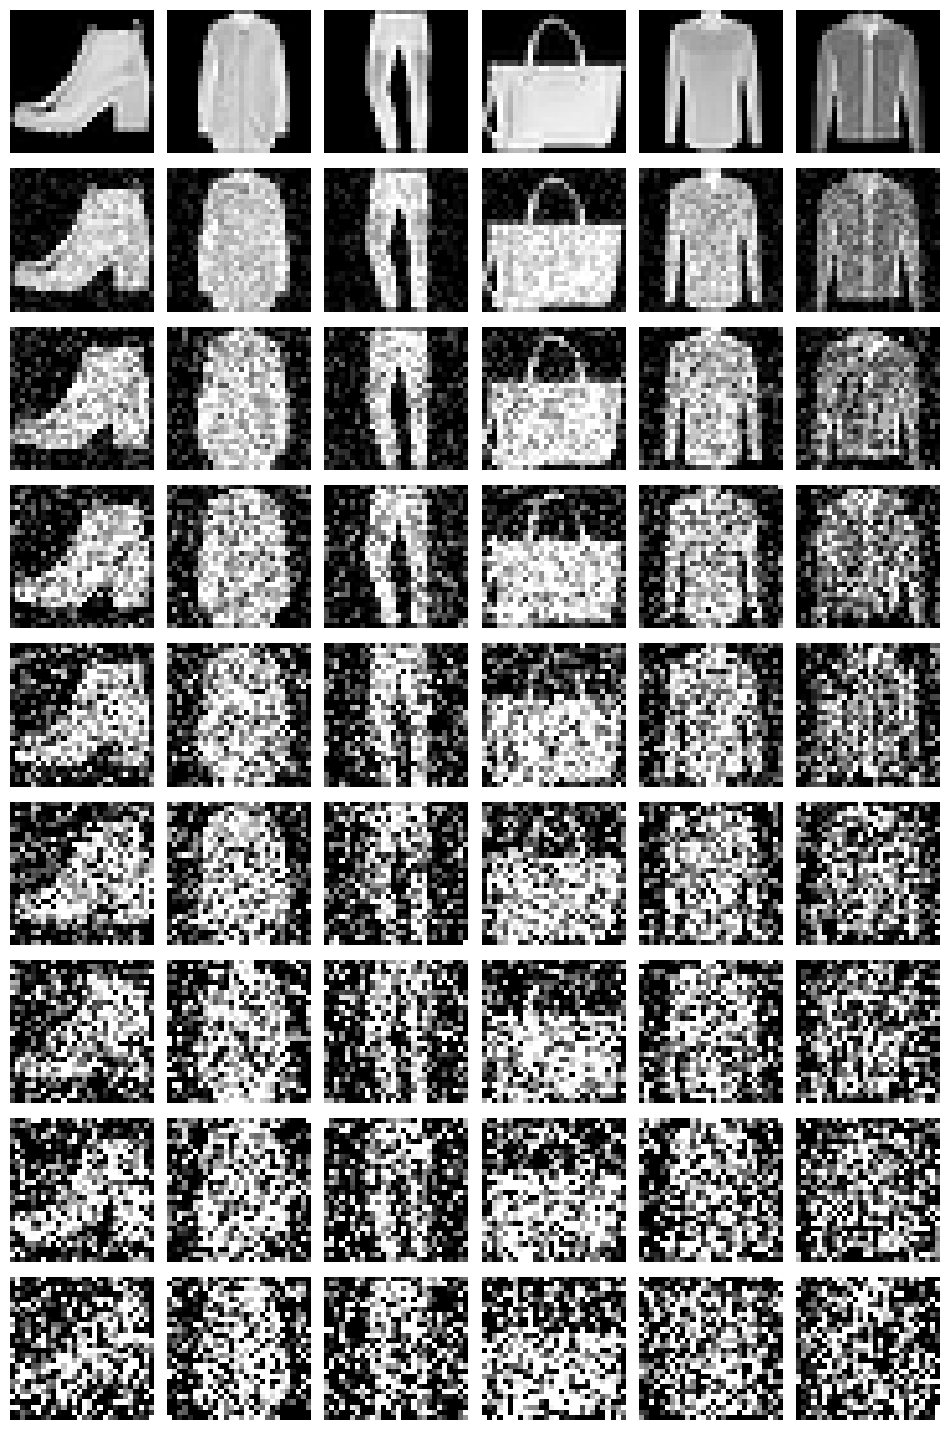

In [4]:
def add_gaussian_noise(images, std=None, std_min=0.1, std_max=0.8):
    """Добавляет гауссовский шум и обрезает значения к диапазону [0, 1]."""
    if std is None:
        std = torch.empty(images.size(0), 1, 1, 1, device=images.device).uniform_(std_min, std_max)
    elif not torch.is_tensor(std):
        std = torch.full((images.size(0), 1, 1, 1), float(std), device=images.device)
    noisy = images + torch.randn_like(images) * std
    return torch.clamp(noisy, 0.0, 1.0), std
def show_noise_examples(loader, noise_stds=(0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8), n=6):
    images, _ = next(iter(loader))
    images = images[:n].to(device)
    fig, axes = plt.subplots(len(noise_stds) + 1, n, figsize=(1.6 * n, 1.6 * (len(noise_stds) + 1)))
    for i in range(n):
        axes[0, i].imshow(images[i, 0].cpu(), cmap="gray")
        axes[0, i].axis("off")
        if i == 0:
            axes[0, i].set_ylabel("оригинал")
    for row, std in enumerate(noise_stds, start=1):
        noisy, _ = add_gaussian_noise(images, std=std)
        for i in range(n):
            axes[row, i].imshow(noisy[i, 0].cpu(), cmap="gray")
            axes[row, i].axis("off")
            if i == 0:
                axes[row, i].set_ylabel(f"std={std}")
    plt.tight_layout()
    plt.show()
show_noise_examples(test_loader)


## Модель

Сверточный denoising autoencoder: encoder сжимает `1x28x28` в latent-вектор, decoder восстанавливает изображение.


In [5]:
class DenoisingConvAutoencoder(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()
        self.encoder_cnn = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.SiLU(inplace=True),
            nn.MaxPool2d(2),  # 14x14
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.SiLU(inplace=True),
            nn.MaxPool2d(2),  # 7x7
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.SiLU(inplace=True),
        )
        self.flatten = nn.Flatten()
        self.to_latent = nn.Linear(128 * 7 * 7, latent_dim)
        self.from_latent = nn.Linear(latent_dim, 128 * 7 * 7)
        self.decoder_cnn = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2),  # 14x14
            nn.BatchNorm2d(64),
            nn.SiLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.SiLU(inplace=True),
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),  # 28x28
            nn.BatchNorm2d(32),
            nn.SiLU(inplace=True),
            nn.Conv2d(32, 1, kernel_size=3, padding=1),
            nn.Sigmoid(),
        )
    def encode(self, x):
        features = self.encoder_cnn(x)
        return self.to_latent(self.flatten(features))
    def decode(self, z):
        features = self.from_latent(z).view(-1, 128, 7, 7)
        return self.decoder_cnn(features)
    def forward(self, x):
        z = self.encode(x)
        return self.decode(z)
example_model = DenoisingConvAutoencoder(latent_dim=64).to(device)
print(f"Parameters with latent_dim=64: {sum(p.numel() for p in example_model.parameters() if p.requires_grad):,}")
del example_model


Parameters with latent_dim=64: 980,737


## Метрики

Используются `MSE`, `PSNR`, `SSIM`.


In [6]:
def mse_per_image(pred, target):
    return (pred - target).pow(2).flatten(1).mean(dim=1)
def psnr_from_mse(mse, max_value=1.0):
    return 10.0 * torch.log10((max_value ** 2) / (mse + 1e-8))
def simple_ssim(pred, target, max_value=1.0):
    # Упрощенная SSIM по всему изображению. Для сравнения моделей этого достаточно.
    pred_flat = pred.flatten(1)
    target_flat = target.flatten(1)
    mu_x = pred_flat.mean(dim=1)
    mu_y = target_flat.mean(dim=1)
    var_x = pred_flat.var(dim=1, unbiased=False)
    var_y = target_flat.var(dim=1, unbiased=False)
    cov_xy = ((pred_flat - mu_x[:, None]) * (target_flat - mu_y[:, None])).mean(dim=1)
    c1 = (0.01 * max_value) ** 2
    c2 = (0.03 * max_value) ** 2
    return ((2 * mu_x * mu_y + c1) * (2 * cov_xy + c2)) / ((mu_x ** 2 + mu_y ** 2 + c1) * (var_x + var_y + c2))


## Optuna и финальное обучение

Validation используется для выбора гиперпараметров; test set используется только для итоговой оценки.


In [7]:
criterion = nn.MSELoss()
def train_one_epoch(model, loader, optimizer, train_noise_std=None):
    model.train()
    running_loss = 0.0
    total = 0
    for images, _ in loader:
        images = images.to(device, non_blocking=True)
        if train_noise_std is None:
            noisy_images, _ = add_gaussian_noise(
                images,
                std=None,
                std_min=NOISE_STD_MIN,
                std_max=NOISE_STD_MAX,
            )
        else:
            noisy_images, _ = add_gaussian_noise(images, std=train_noise_std)
        optimizer.zero_grad(set_to_none=True)
        reconstructed = model(noisy_images)
        loss = criterion(reconstructed, images)
        loss.backward()
        optimizer.step()
        batch_size = images.size(0)
        running_loss += loss.item() * batch_size
        total += batch_size
    return running_loss / total
@torch.no_grad()
def evaluate(model, loader, noise_std=0.3):
    model.eval()
    total_mse = 0.0
    total_psnr = 0.0
    total_ssim = 0.0
    total = 0
    for images, _ in loader:
        images = images.to(device, non_blocking=True)
        noisy_images, _ = add_gaussian_noise(images, std=noise_std)
        reconstructed = model(noisy_images)
        mse_values = mse_per_image(reconstructed, images)
        psnr_values = psnr_from_mse(mse_values)
        ssim_values = simple_ssim(reconstructed, images)
        batch_size = images.size(0)
        total_mse += mse_values.sum().item()
        total_psnr += psnr_values.sum().item()
        total_ssim += ssim_values.sum().item()
        total += batch_size
    return {
        "noise_std": noise_std,
        "mse": total_mse / total,
        "psnr": total_psnr / total,
        "ssim": total_ssim / total,
    }
def fit_model(config, epochs, train_loader, val_loader, train_noise_std=None, eval_noise_std=0.4, verbose=True):
    model = DenoisingConvAutoencoder(latent_dim=config["latent_dim"]).to(device)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"],
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    history = []
    for epoch in range(1, epochs + 1):
        train_mse = train_one_epoch(model, train_loader, optimizer, train_noise_std=train_noise_std)
        val_metrics = evaluate(model, val_loader, noise_std=eval_noise_std)
        scheduler.step()
        row = {"epoch": epoch, "train_mse": train_mse, **val_metrics}
        history.append(row)
        if verbose:
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"train MSE: {train_mse:.5f} | "
                f"val MSE: {val_metrics['mse']:.5f} | "
                f"PSNR: {val_metrics['psnr']:.2f} | "
                f"SSIM: {val_metrics['ssim']:.4f}"
            )
    return model, history
def objective(trial):
    config = {
        "latent_dim": trial.suggest_categorical("latent_dim", [32, 64, 128]),
        "lr": trial.suggest_float("lr", 1e-4, 1e-3, log=True),
        "weight_decay": trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True),
    }
    print(f"Optuna trial {trial.number}: {config}")
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    candidate_model, candidate_history = fit_model(
        config,
        SEARCH_EPOCHS,
        train_loader,
        val_loader,
        eval_noise_std=0.4,
        verbose=False,
    )
    val_results = [evaluate(candidate_model, val_loader, noise_std=std) for std in EVAL_NOISE_STDS]
    avg_mse = sum(row["mse"] for row in val_results) / len(val_results)
    avg_psnr = sum(row["psnr"] for row in val_results) / len(val_results)
    avg_ssim = sum(row["ssim"] for row in val_results) / len(val_results)
    trial.set_user_attr("last_epoch", candidate_history[-1]["epoch"])
    trial.set_user_attr("avg_psnr", avg_psnr)
    trial.set_user_attr("avg_ssim", avg_ssim)
    print(
        f"avg val MSE over std=0.1..0.8: {avg_mse:.5f} | "
        f"avg PSNR: {avg_psnr:.2f} | "
        f"avg SSIM: {avg_ssim:.4f}"
    )
    del candidate_model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return avg_mse
start_time = time.time()
study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
)
study.optimize(objective, n_trials=OPTUNA_TRIALS)
print("\nOptuna results sorted by validation MSE:")
for trial in sorted(study.trials, key=lambda item: item.value if item.value is not None else float("inf")):
    if trial.value is None:
        continue
    print(
        f"trial={trial.number:02d}, "
        f"latent={trial.params['latent_dim']}, "
        f"lr={trial.params['lr']:.2e}, "
        f"wd={trial.params['weight_decay']:.2e}, "
        f"epoch={trial.user_attrs.get('last_epoch')}, "
        f"MSE={trial.value:.5f}, "
        f"avg PSNR={trial.user_attrs.get('avg_psnr'):.2f}, "
        f"avg SSIM={trial.user_attrs.get('avg_ssim'):.4f}"
    )
best_config = {
    "latent_dim": study.best_params["latent_dim"],
    "lr": study.best_params["lr"],
    "weight_decay": study.best_params["weight_decay"],
}
print(f"\nBest config: {best_config}")
print("\nFinal run on best config")
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
model, history = fit_model(best_config, FINAL_EPOCHS, train_loader, val_loader, eval_noise_std=0.4, verbose=True)
print(f"Optuna search + final training time: {(time.time() - start_time) / 60:.1f} min")


[I 2026-05-28 14:48:14,024] A new study created in memory with name: no-name-e73bda02-67b4-4331-ba53-a60f2c36b064


Optuna trial 0: {'latent_dim': 64, 'lr': 0.00039687933304443713, 'weight_decay': 2.9380279387035354e-06}


[I 2026-05-28 14:50:35,781] Trial 0 finished with value: 0.016511101249605416 and parameters: {'latent_dim': 64, 'lr': 0.00039687933304443713, 'weight_decay': 2.9380279387035354e-06}. Best is trial 0 with value: 0.016511101249605416.


avg val MSE over std=0.1..0.8: 0.01651 | avg PSNR: 18.38 | avg SSIM: 0.8781
Optuna trial 1: {'latent_dim': 128, 'lr': 0.0003991305878561678, 'weight_decay': 0.000133112160807369}


[I 2026-05-28 14:53:19,722] Trial 1 finished with value: 0.015558672616524357 and parameters: {'latent_dim': 128, 'lr': 0.0003991305878561678, 'weight_decay': 0.000133112160807369}. Best is trial 1 with value: 0.015558672616524357.


...

avg val MSE over std=0.1..0.8: 0.01737 | avg PSNR: 18.15 | avg SSIM: 0.8739
Optuna trial 8: {'latent_dim': 64, 'lr': 0.0008115595675970503, 'weight_decay': 5.975027999960295e-06}


[I 2026-05-28 15:11:30,220] Trial 8 finished with value: 0.015655806812324695 and parameters: {'latent_dim': 64, 'lr': 0.0008115595675970503, 'weight_decay': 5.975027999960295e-06}. Best is trial 1 with value: 0.015558672616524357.


avg val MSE over std=0.1..0.8: 0.01566 | avg PSNR: 18.68 | avg SSIM: 0.8853
Optuna trial 9: {'latent_dim': 32, 'lr': 0.0003521358805467869, 'weight_decay': 3.5856126103453987e-06}


[I 2026-05-28 15:14:06,067] Trial 9 finished with value: 0.017889872303498644 and parameters: {'latent_dim': 32, 'lr': 0.0003521358805467869, 'weight_decay': 3.5856126103453987e-06}. Best is trial 1 with value: 0.015558672616524357.


avg val MSE over std=0.1..0.8: 0.01789 | avg PSNR: 17.99 | avg SSIM: 0.8697

Optuna results sorted by validation MSE:
trial=01, latent=128, lr=3.99e-04, wd=1.33e-04, epoch=2, MSE=0.01556, avg PSNR=18.69, avg SSIM=0.8856
trial=08, latent=64, lr=8.12e-04, wd=5.98e-06, epoch=2, MSE=0.01566, avg PSNR=18.68, avg SSIM=0.8853
trial=03, latent=128, lr=2.70e-04, wd=7.48e-06, epoch=2, MSE=0.01618, avg PSNR=18.47, avg SSIM=0.8806
trial=00, latent=64, lr=3.97e-04, wd=2.94e-06, epoch=2, MSE=0.01651, avg PSNR=18.38, avg SSIM=0.8781
trial=06, latent=32, lr=8.89e-04, wd=7.89e-04, epoch=2, MSE=0.01666, avg PSNR=18.37, avg SSIM=0.8801
trial=07, latent=32, lr=4.83e-04, wd=2.09e-05, epoch=2, MSE=0.01737, avg PSNR=18.15, avg SSIM=0.8739
trial=05, latent=32, lr=3.91e-04, wd=1.38e-06, epoch=2, MSE=0.01769, avg PSNR=18.05, avg SSIM=0.8711
trial=09, latent=32, lr=3.52e-04, wd=3.59e-06, epoch=2, MSE=0.01789, avg PSNR=17.99, avg SSIM=0.8697
trial=02, latent=64, lr=1.63e-04, wd=3.51e-06, epoch=2, MSE=0.01865, avg

## График финального обучения


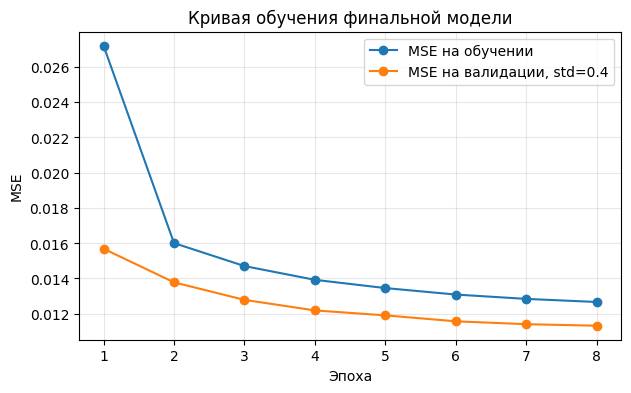

In [8]:
epochs = [row["epoch"] for row in history]
train_mse = [row["train_mse"] for row in history]
val_mse = [row["mse"] for row in history]
plt.figure(figsize=(7, 4))
plt.plot(epochs, train_mse, marker="o", label="MSE на обучении")
plt.plot(epochs, val_mse, marker="o", label="MSE на валидации, std=0.4")
plt.xlabel("Эпоха")
plt.ylabel("MSE")
plt.title("Кривая обучения финальной модели")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


## Test set: разные уровни шума


In [9]:
results = [evaluate(model, test_loader, noise_std=std) for std in EVAL_NOISE_STDS]
print(" noise_std |   MSE   |  PSNR  |  SSIM")
print("-----------|---------|--------|--------")
for row in results:
    print(f"   {row['noise_std']:.1f}     | {row['mse']:.5f} | {row['psnr']:.2f} | {row['ssim']:.4f}")


 noise_std |   MSE   |  PSNR  |  SSIM
-----------|---------|--------|--------
   0.1     | 0.00809 | 21.82 | 0.9425
   0.2     | 0.00873 | 21.40 | 0.9376
   0.3     | 0.00986 | 20.76 | 0.9289
   0.4     | 0.01140 | 20.03 | 0.9175
   0.5     | 0.01326 | 19.30 | 0.9046
   0.6     | 0.01534 | 18.62 | 0.8901
   0.7     | 0.01747 | 18.02 | 0.8755
   0.8     | 0.01977 | 17.45 | 0.8598


## Примеры восстановления

Финальная модель проверяется на одних и тех же картинках с `std=0.1`, `0.2`, `0.3`, `0.4`, `0.5`, `0.6`, `0.7`, `0.8`.


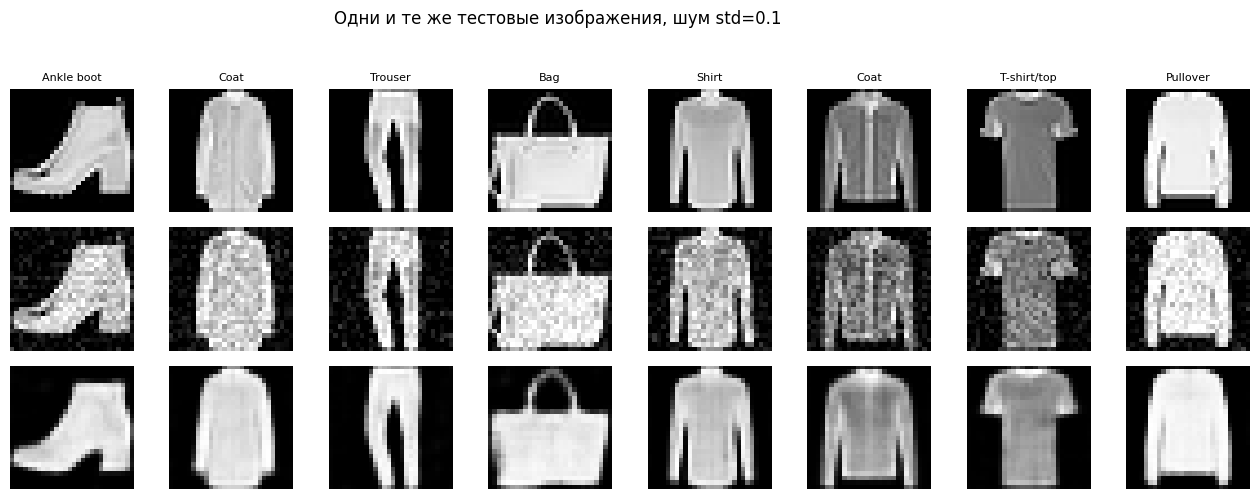

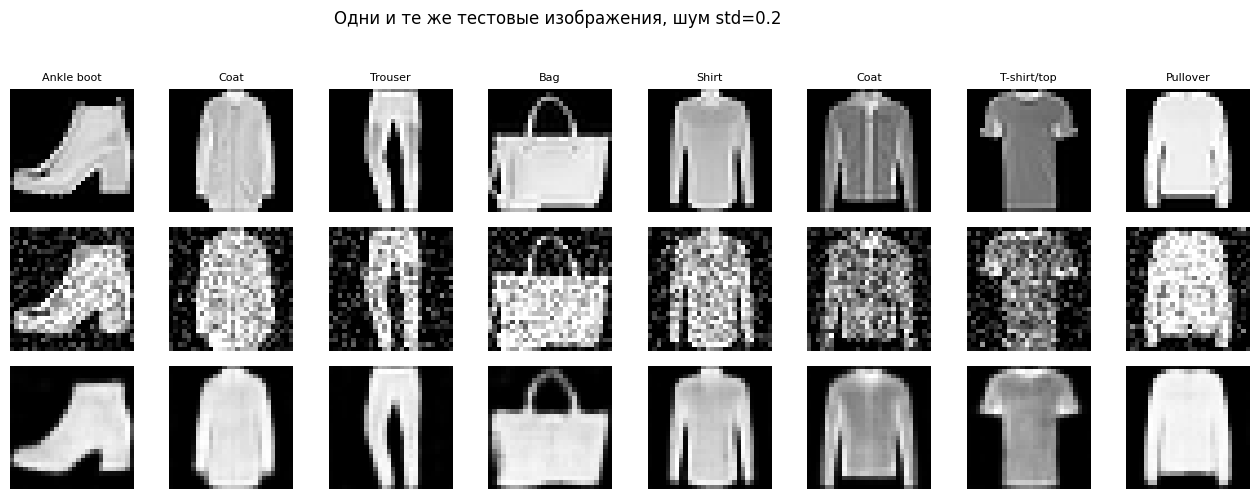

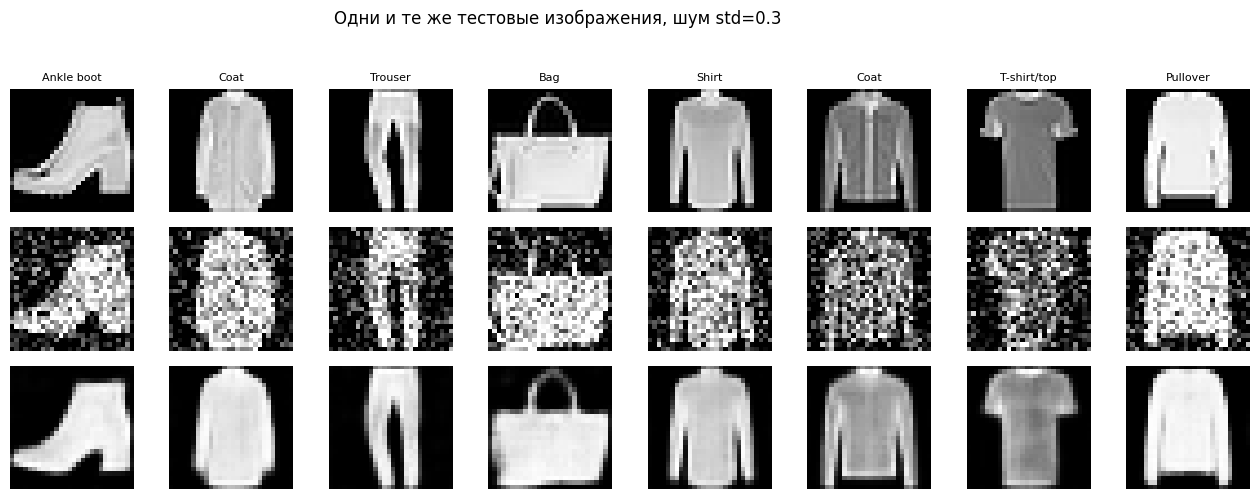

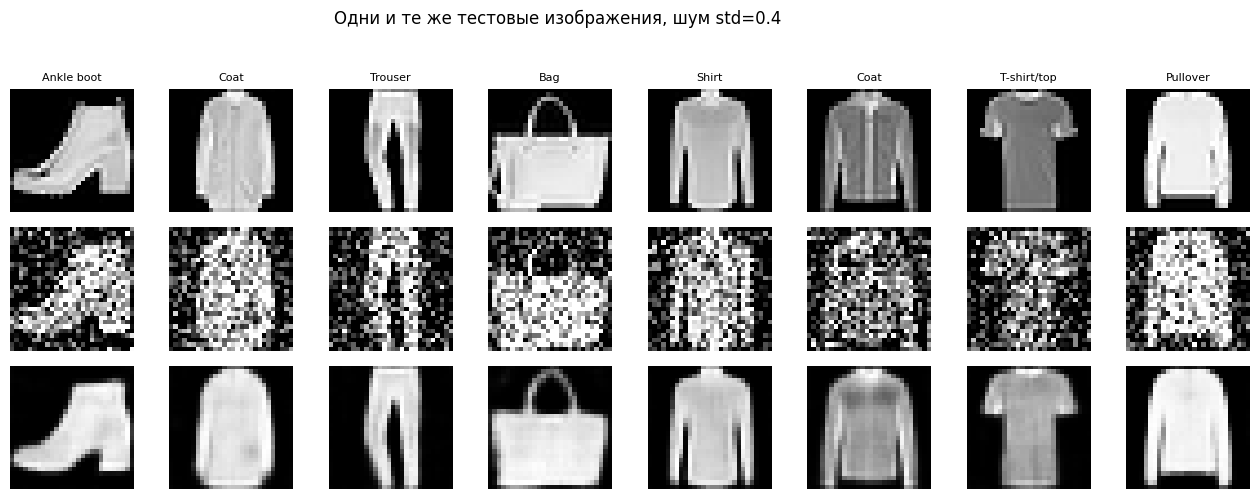

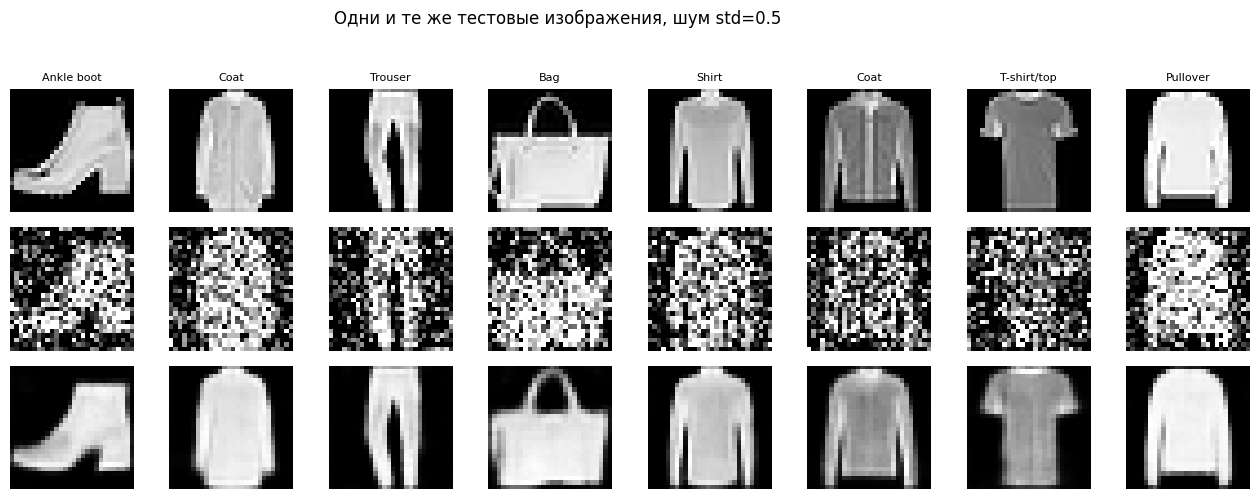

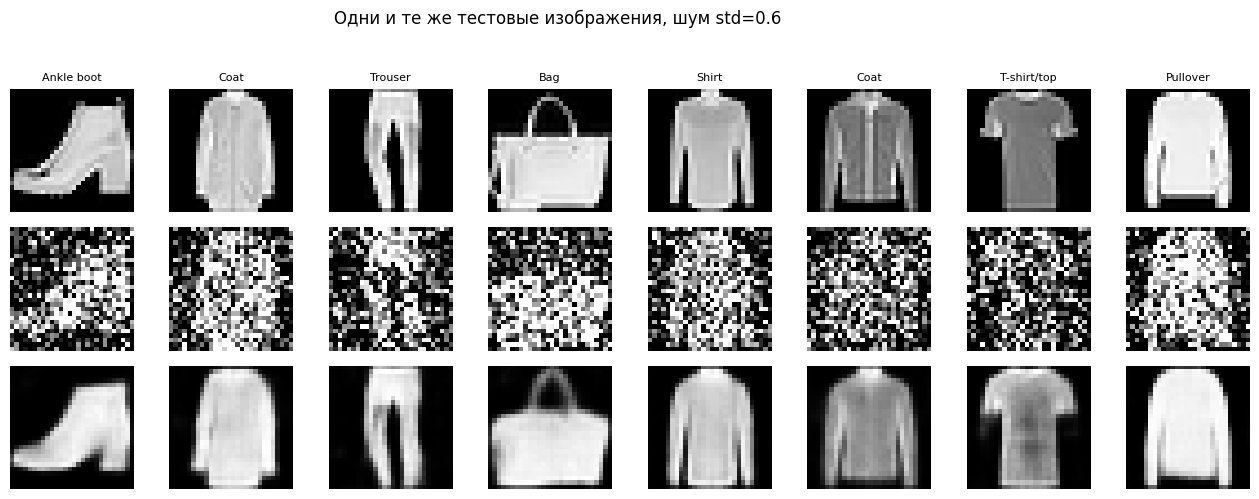

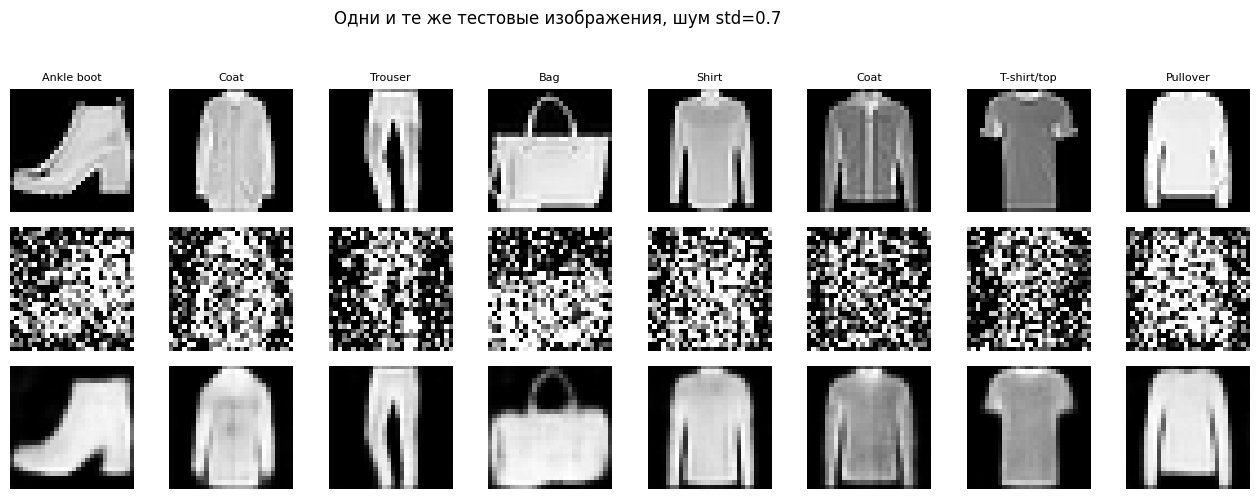

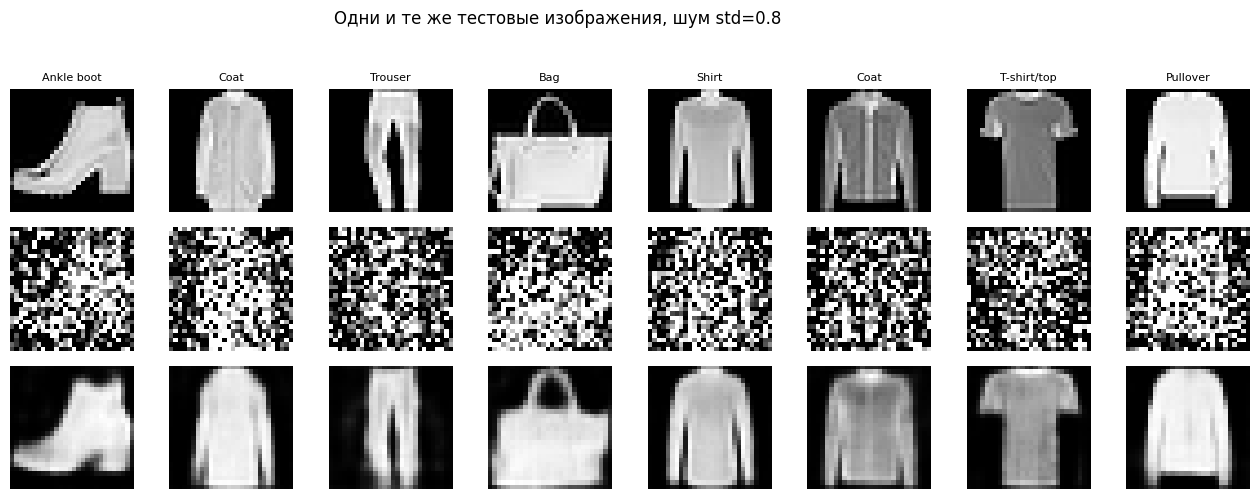

In [10]:
@torch.no_grad()
def show_reconstructions_for_noise_levels(model, loader, noise_stds=(0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8), n=8):
    model.eval()
    images, labels = next(iter(loader))
    images = images[:n].to(device)
    labels = labels[:n]
    for noise_std in noise_stds:
        torch.manual_seed(SEED + int(noise_std * 1000))
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(SEED + int(noise_std * 1000))
        noisy_images, _ = add_gaussian_noise(images, std=noise_std)
        reconstructed = model(noisy_images)
        rows = [
            ("оригинал", images),
            (f"шум std={noise_std}", noisy_images),
            ("восстановлено", reconstructed),
        ]
        fig, axes = plt.subplots(len(rows), n, figsize=(1.8 * n, 5.0))
        fig.suptitle(f"Одни и те же тестовые изображения, шум std={noise_std}", y=0.99)
        for row_idx, (row_name, batch) in enumerate(rows):
            for col_idx in range(n):
                axes[row_idx, col_idx].imshow(batch[col_idx, 0].cpu(), cmap="gray")
                axes[row_idx, col_idx].axis("off")
                if row_idx == 0:
                    axes[row_idx, col_idx].set_title(classes[labels[col_idx]], fontsize=8)
                if col_idx == 0:
                    axes[row_idx, col_idx].set_ylabel(row_name, rotation=0, ha="right", va="center", labelpad=58)
        plt.tight_layout(rect=(0.10, 0.00, 1.00, 0.96))
        plt.show()
show_reconstructions_for_noise_levels(model, test_loader, noise_stds=EVAL_NOISE_STDS, n=8)


## PCA latent space

Цвет точки соответствует классу Fashion-MNIST.


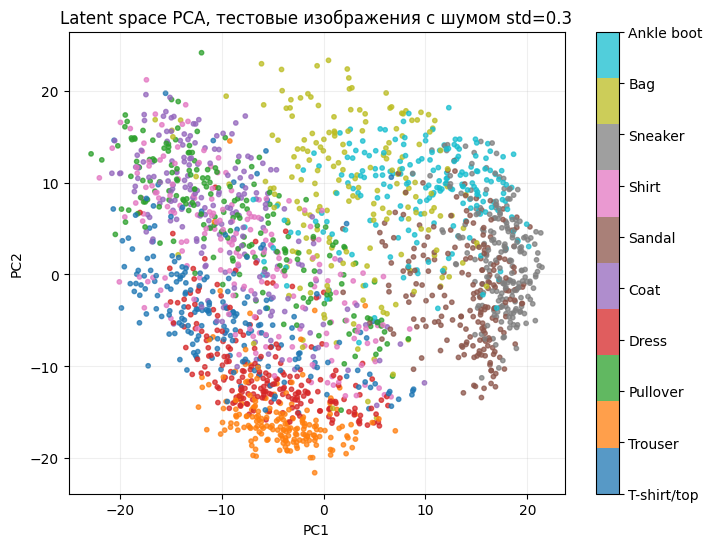

In [11]:
@torch.no_grad()
def collect_latents(model, loader, max_samples=2000, noise_std=0.3):
    model.eval()
    latents = []
    labels_all = []
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        noisy_images, _ = add_gaussian_noise(images, std=noise_std)
        z = model.encode(noisy_images)
        latents.append(z.cpu())
        labels_all.append(labels)
        if sum(x.size(0) for x in latents) >= max_samples:
            break
    latents = torch.cat(latents, dim=0)[:max_samples].numpy()
    labels_all = torch.cat(labels_all, dim=0)[:max_samples].numpy()
    return latents, labels_all
latents, latent_labels = collect_latents(model, test_loader, max_samples=2000, noise_std=0.3)
if SKLEARN_AVAILABLE:
    from sklearn.decomposition import PCA
    pca_points = PCA(n_components=2, random_state=SEED).fit_transform(latents)
else:
    latents_tensor = torch.tensor(latents, dtype=torch.float32)
    centered = latents_tensor - latents_tensor.mean(dim=0, keepdim=True)
    _, _, components = torch.pca_lowrank(centered, q=2)
    pca_points = (centered @ components[:, :2]).numpy()
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    pca_points[:, 0],
    pca_points[:, 1],
    c=latent_labels,
    cmap="tab10",
    s=10,
    alpha=0.75,
)
cbar = plt.colorbar(scatter, ticks=range(10))
cbar.ax.set_yticklabels(classes)
plt.title("Latent space PCA, тестовые изображения с шумом std=0.3")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.2)
plt.show()


## t-SNE

По умолчанию выключено, потому что работает дольше PCA.


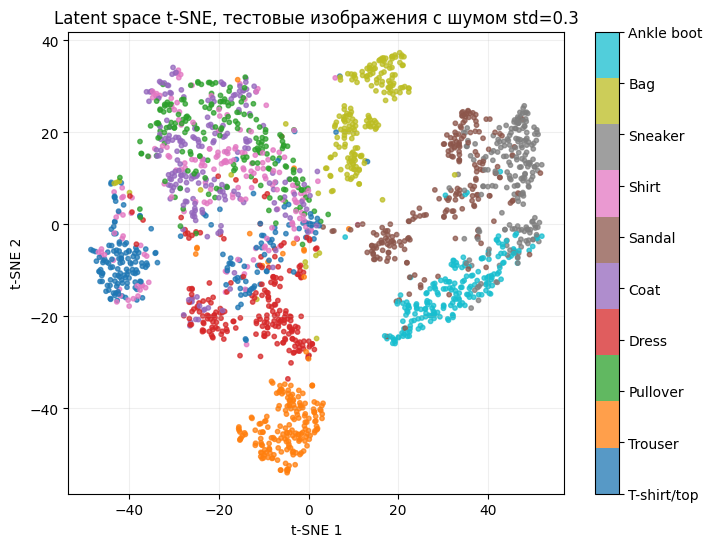

In [12]:
RUN_TSNE = True
if RUN_TSNE and not SKLEARN_AVAILABLE:
    print("t-SNE requires scikit-learn. Install it or use the PCA visualization above.")
elif RUN_TSNE:
    from sklearn.manifold import TSNE
    tsne_points = TSNE(
        n_components=2,
        perplexity=30,
        learning_rate="auto",
        init="pca",
        random_state=SEED,
    ).fit_transform(latents)
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(
        tsne_points[:, 0],
        tsne_points[:, 1],
        c=latent_labels,
        cmap="tab10",
        s=10,
        alpha=0.75,
    )
    cbar = plt.colorbar(scatter, ticks=range(10))
    cbar.ax.set_yticklabels(classes)
    plt.title("Latent space t-SNE, тестовые изображения с шумом std=0.3")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.grid(alpha=0.2)
    plt.show()
else:
    print("t-SNE skipped. Set RUN_TSNE = True to run it.")


## Исследование специализированных моделей

Дополнительно обучаются две модели: только на `std=0.1` и только на `std=0.8`. Каждая проверяется на всех уровнях шума от `0.1` до `0.8`.



Training specialized model only on std=0.1
Epoch 01/8 | train MSE: 0.02526 | val MSE: 0.01046 | PSNR: 20.37 | SSIM: 0.9241
Epoch 02/8 | train MSE: 0.00878 | val MSE: 0.00787 | PSNR: 21.81 | SSIM: 0.9445
Epoch 03/8 | train MSE: 0.00720 | val MSE: 0.00676 | PSNR: 22.59 | SSIM: 0.9525
Epoch 04/8 | train MSE: 0.00638 | val MSE: 0.00623 | PSNR: 22.97 | SSIM: 0.9563
Epoch 05/8 | train MSE: 0.00592 | val MSE: 0.00585 | PSNR: 23.30 | SSIM: 0.9588
Epoch 06/8 | train MSE: 0.00559 | val MSE: 0.00561 | PSNR: 23.51 | SSIM: 0.9601
Epoch 07/8 | train MSE: 0.00540 | val MSE: 0.00550 | PSNR: 23.61 | SSIM: 0.9609
Epoch 08/8 | train MSE: 0.00528 | val MSE: 0.00541 | PSNR: 23.71 | SSIM: 0.9617

Test metrics for model trained only on std=0.1
 noise_std |   MSE   |  PSNR  |  SSIM
-----------|---------|--------|--------
   0.1     | 0.00545 | 23.67 | 0.9618
   0.2     | 0.00780 | 21.66 | 0.9434
   0.3     | 0.01409 | 18.74 | 0.8955
   0.4     | 0.02521 | 16.09 | 0.8178
   0.5     | 0.03887 | 14.18 | 0.7295


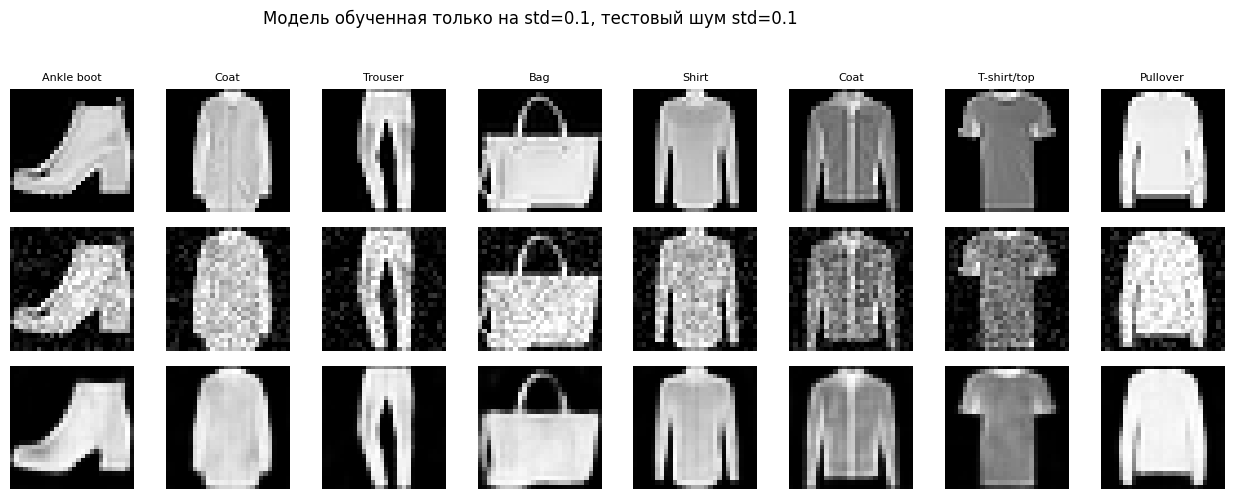

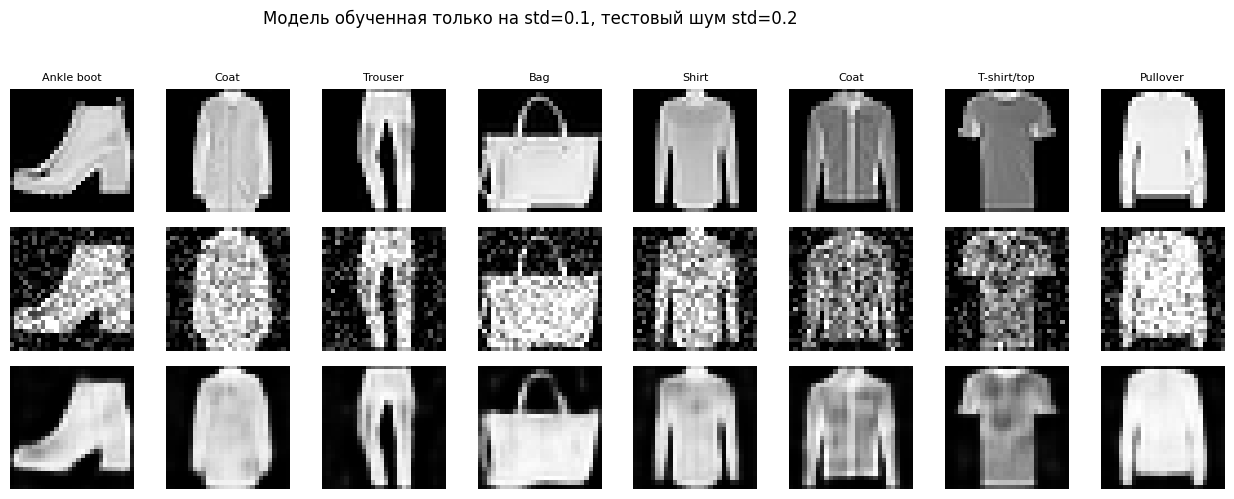

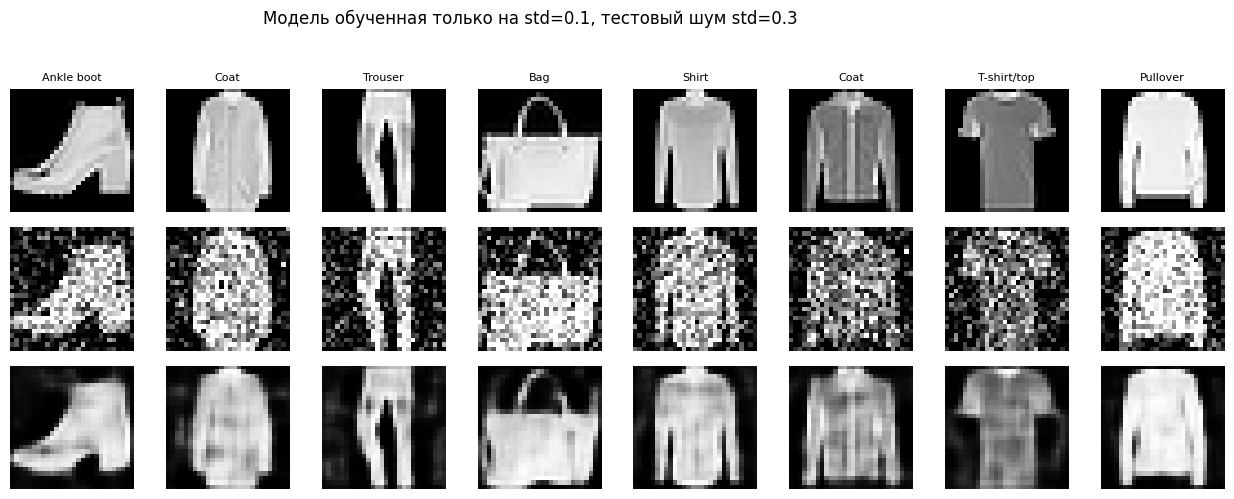

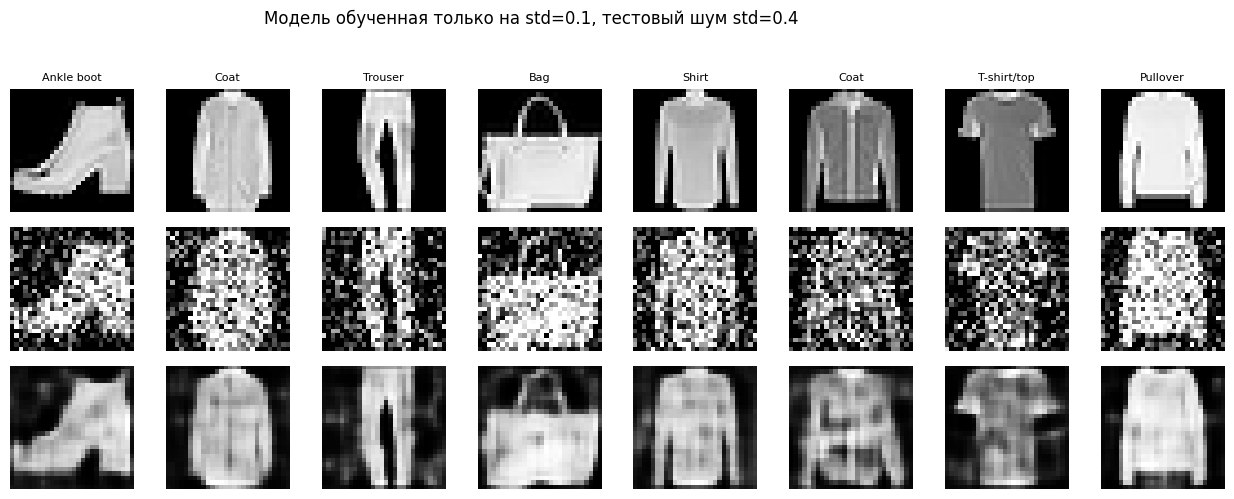

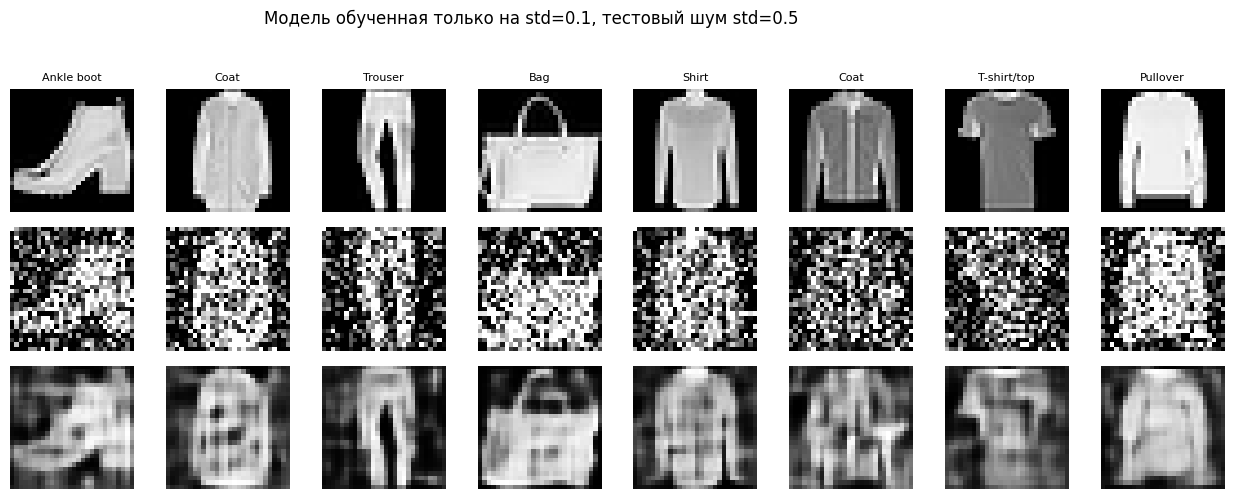

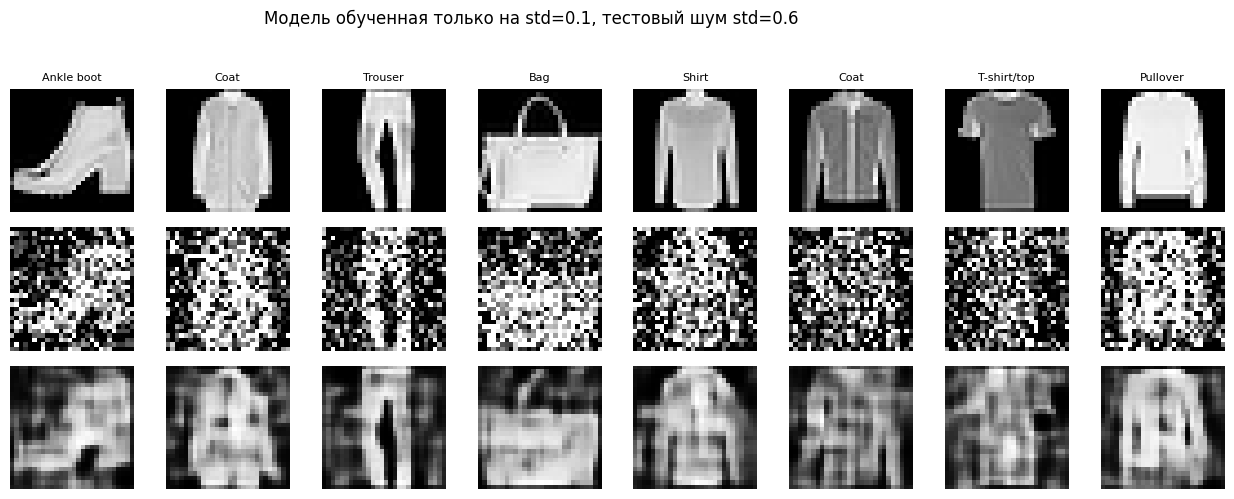

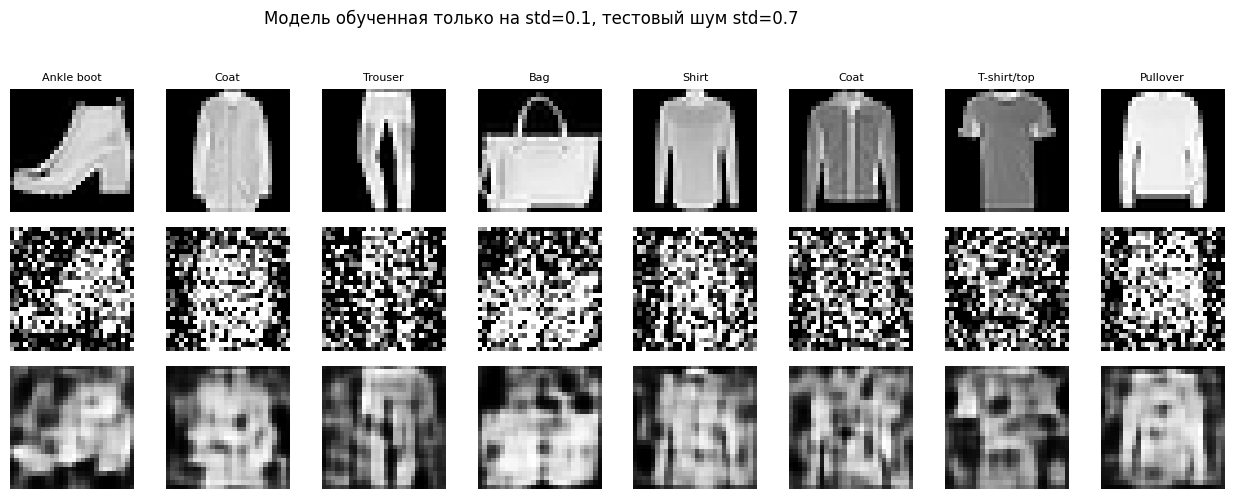

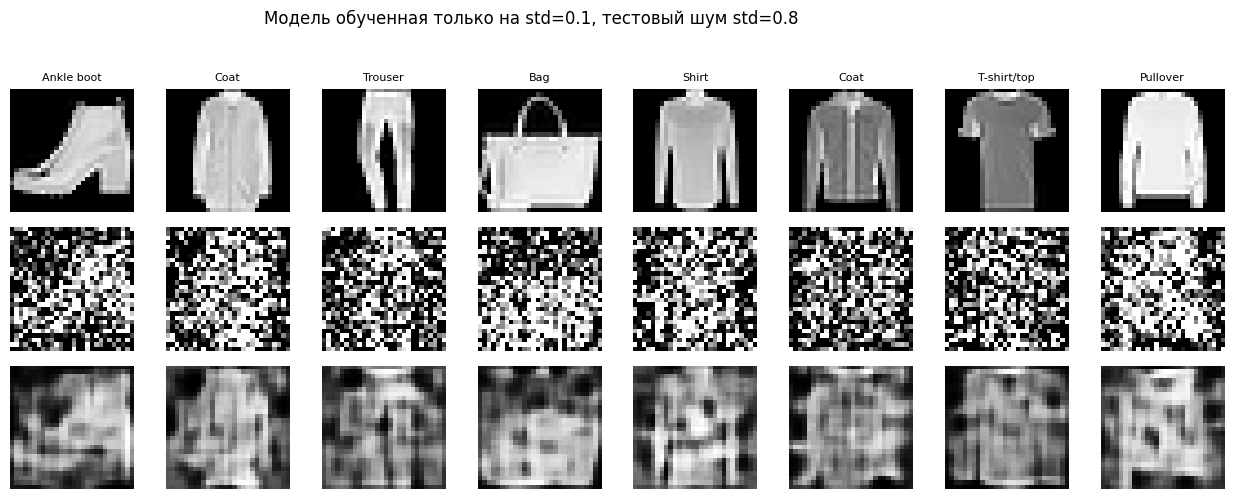

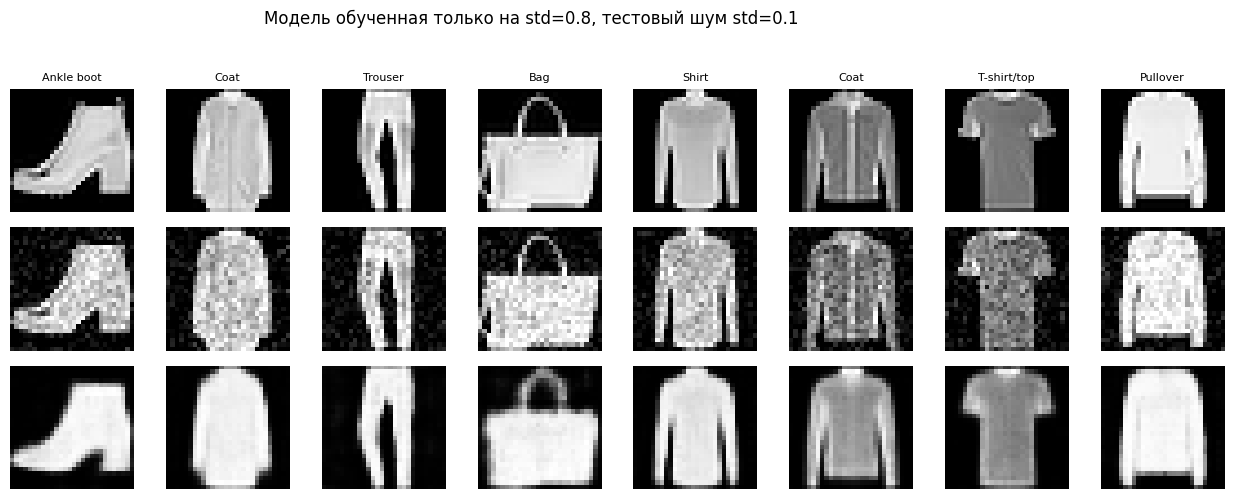

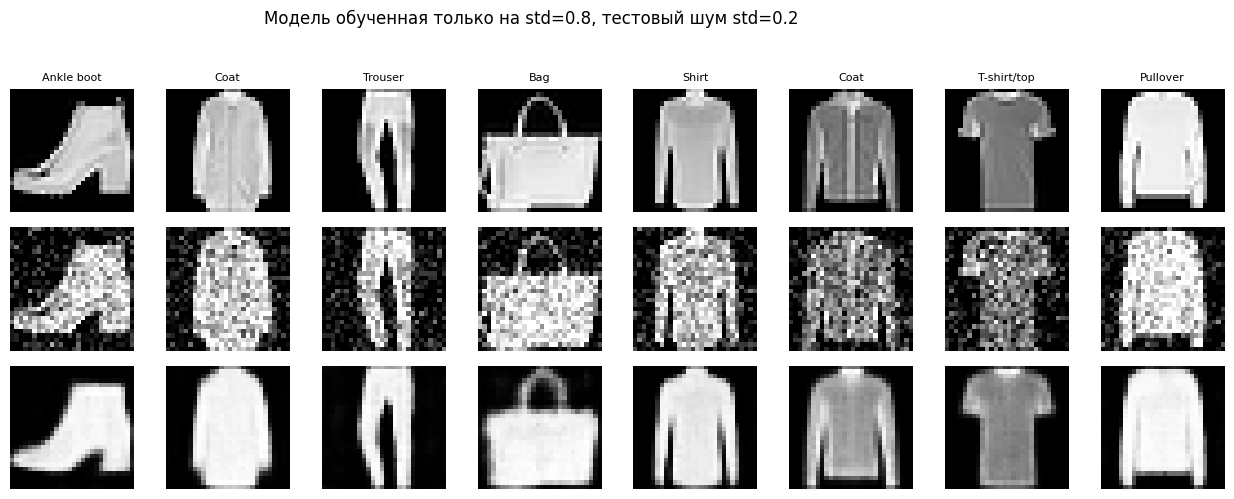

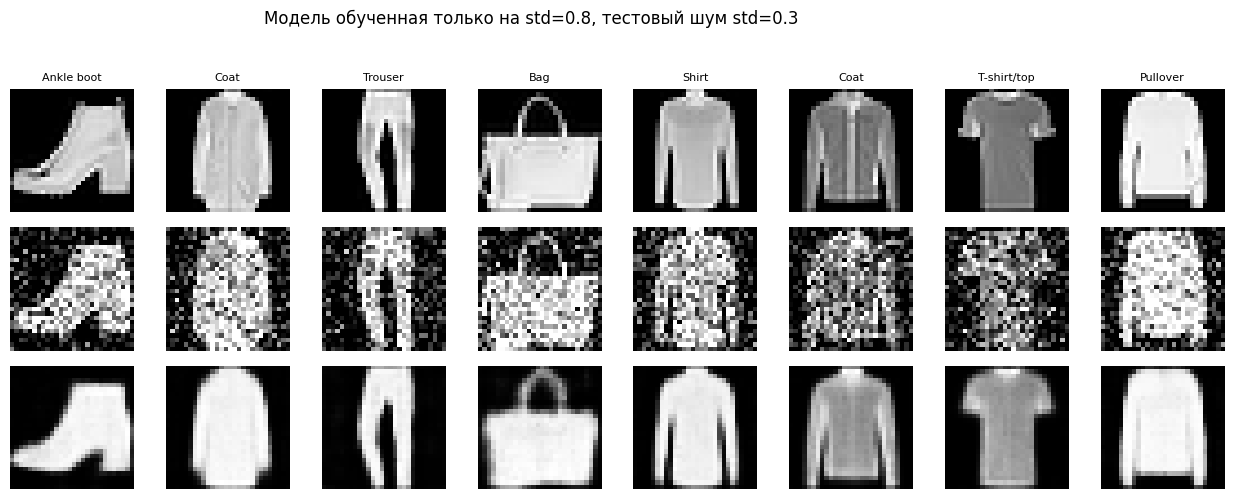

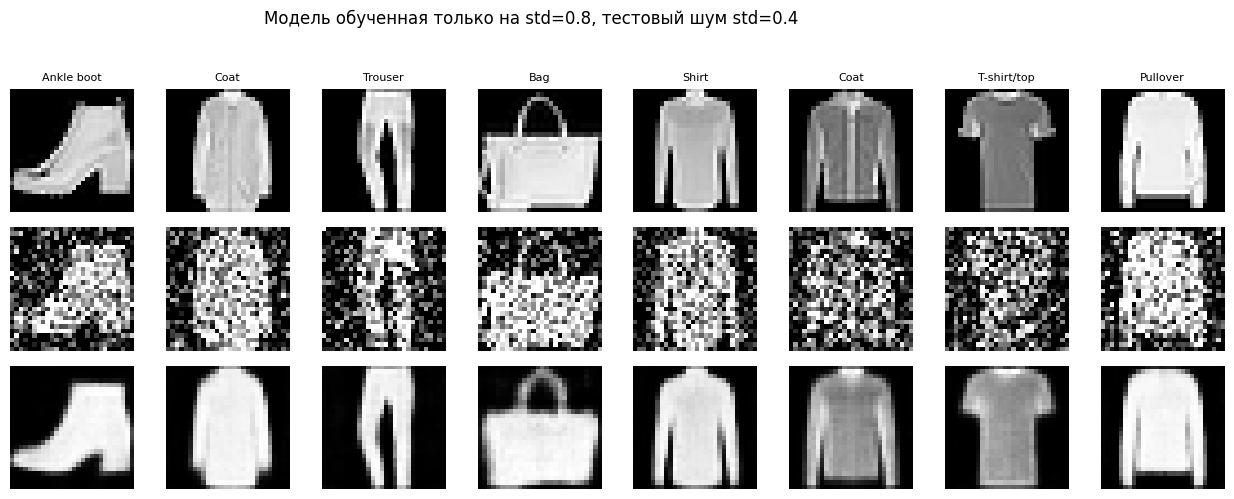

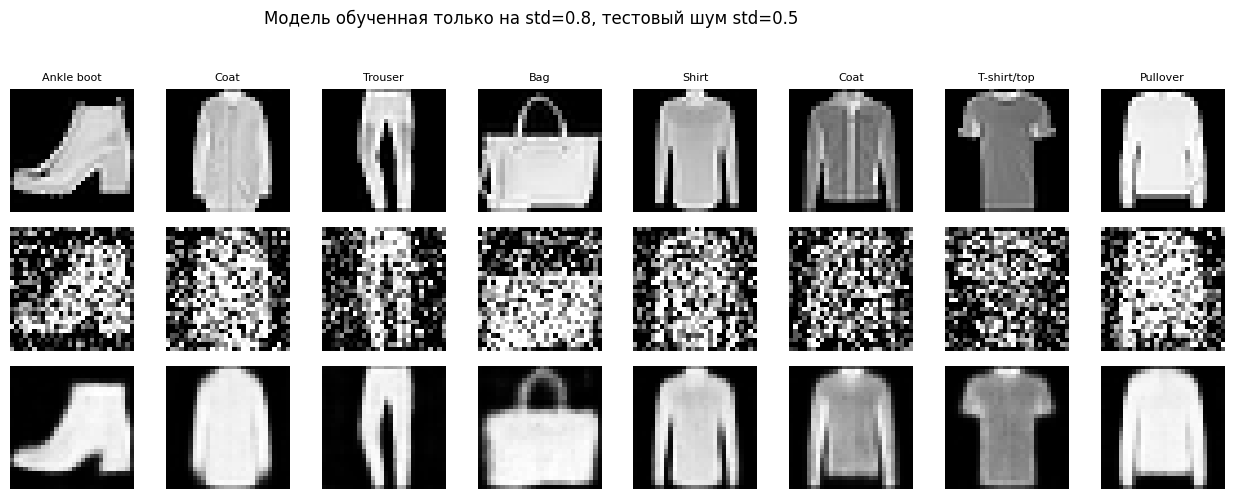

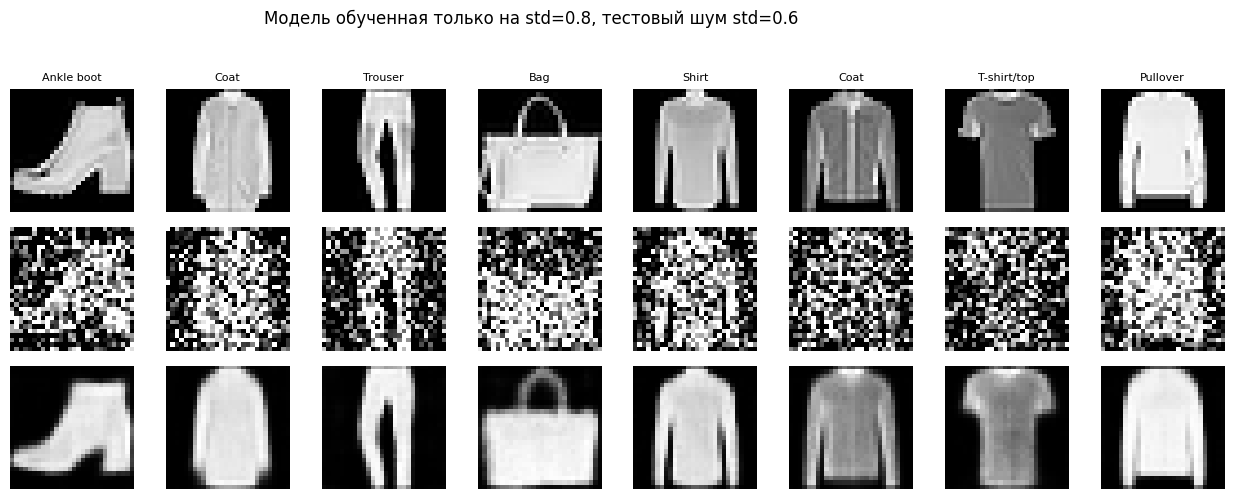

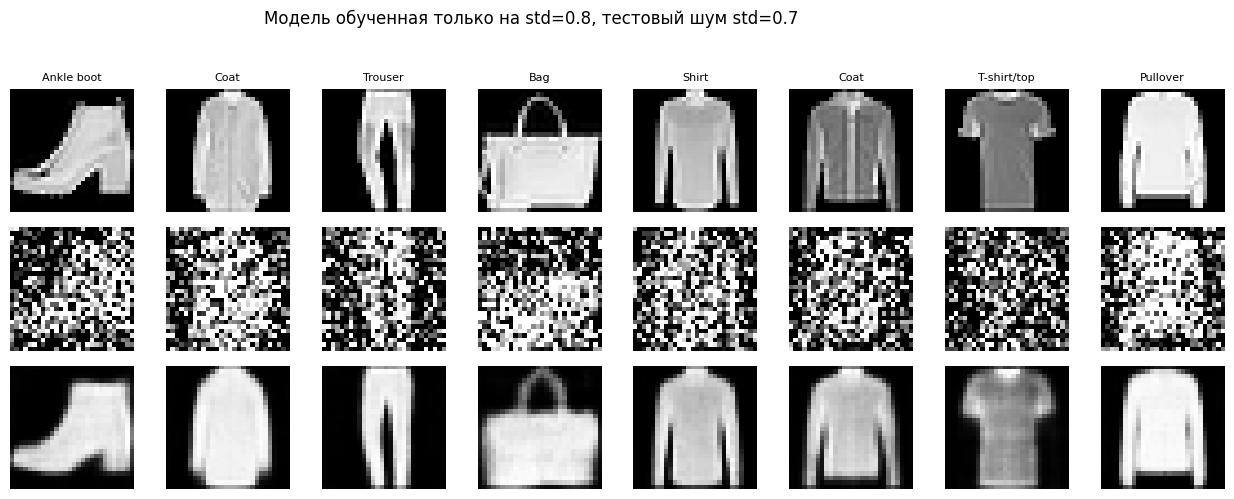

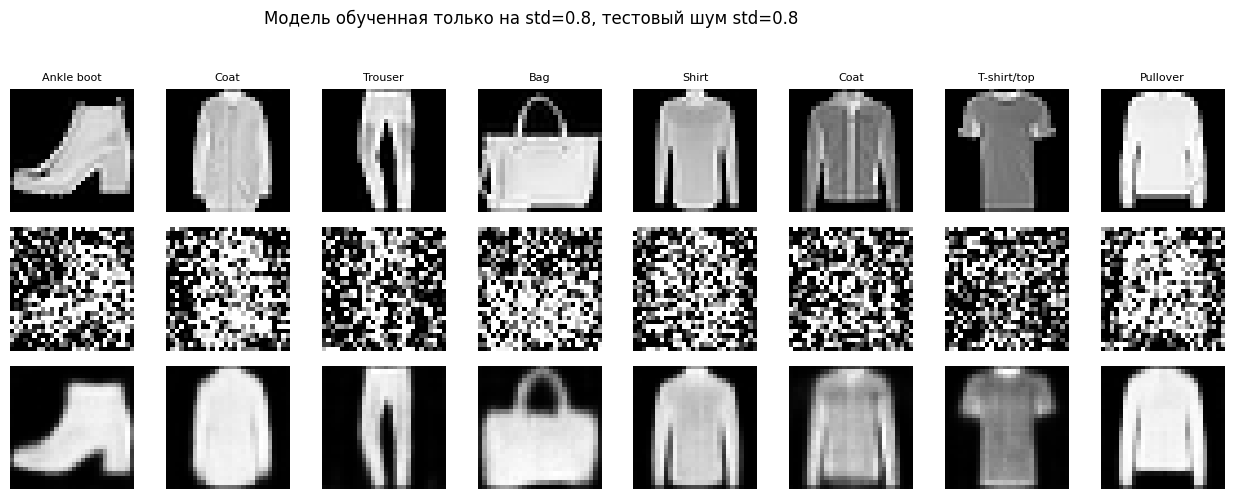

In [13]:
FIXED_STD_EPOCHS = FINAL_EPOCHS
FIXED_TRAIN_STDS = [0.1, 0.8]


def print_metrics_table(title, rows):
    print(title)
    print(" noise_std |   MSE   |  PSNR  |  SSIM")
    print("-----------|---------|--------|--------")
    for row in rows:
        print(f"   {row['noise_std']:.1f}     | {row['mse']:.5f} | {row['psnr']:.2f} | {row['ssim']:.4f}")


fixed_std_results = {}
fixed_std_models = {}

for fixed_std in FIXED_TRAIN_STDS:
    print(f"\nTraining specialized model only on std={fixed_std}")
    torch.manual_seed(SEED + int(fixed_std * 1000))
    torch.cuda.manual_seed_all(SEED + int(fixed_std * 1000))

    fixed_model, fixed_history = fit_model(
        best_config,
        FIXED_STD_EPOCHS,
        train_loader,
        val_loader,
        train_noise_std=fixed_std,
        eval_noise_std=fixed_std,
        verbose=True,
    )

    fixed_results = [evaluate(fixed_model, test_loader, noise_std=std) for std in EVAL_NOISE_STDS]
    fixed_std_models[fixed_std] = fixed_model
    fixed_std_results[fixed_std] = fixed_results
    print_metrics_table(f"\nTest metrics for model trained only on std={fixed_std}", fixed_results)

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


@torch.no_grad()
def show_specialized_reconstructions(models_by_std, loader, noise_stds=EVAL_NOISE_STDS, n=8):
    images, labels = next(iter(loader))
    images = images[:n].to(device)
    labels = labels[:n]

    for train_std, current_model in models_by_std.items():
        current_model.eval()
        for noise_std in noise_stds:
            torch.manual_seed(SEED + int(train_std * 1000) + int(noise_std * 100))
            if torch.cuda.is_available():
                torch.cuda.manual_seed_all(SEED + int(train_std * 1000) + int(noise_std * 100))

            noisy_images, _ = add_gaussian_noise(images, std=noise_std)
            reconstructed = current_model(noisy_images)
            rows = [
                ("оригинал", images),
                (f"шум std={noise_std}", noisy_images),
                (f"восстановление train std={train_std}", reconstructed),
            ]

            fig, axes = plt.subplots(len(rows), n, figsize=(1.8 * n, 5.0))
            fig.suptitle(
                f"Модель обученная только на std={train_std}, тестовый шум std={noise_std}",
                y=0.99,
            )

            for row_idx, (row_name, batch) in enumerate(rows):
                for col_idx in range(n):
                    axes[row_idx, col_idx].imshow(batch[col_idx, 0].cpu(), cmap="gray")
                    axes[row_idx, col_idx].axis("off")
                    if row_idx == 0:
                        axes[row_idx, col_idx].set_title(classes[labels[col_idx]], fontsize=8)
                    if col_idx == 0:
                        axes[row_idx, col_idx].set_ylabel(
                            row_name,
                            rotation=0,
                            ha="right",
                            va="center",
                            labelpad=70,
                        )

            plt.tight_layout(rect=(0.12, 0.00, 1.00, 0.96))
            plt.show()


show_specialized_reconstructions(fixed_std_models, test_loader, noise_stds=EVAL_NOISE_STDS, n=8)



## Вывод

В ноутбуке обучается основная CNN-модель на смешанном гауссовском шуме `std=0.1..0.8`. Гиперпараметры выбираются через Optuna, затем финальная модель оценивается на test set при `std=0.1..0.8`. В конце дополнительно сравниваются специализированные модели, обученные только на `std=0.1` и только на `std=0.8`.
